In [23]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

%matplotlib inline

In [24]:
df = pd.read_csv("amz_uk_price_prediction_dataset.csv")

In [25]:
df.head()

,uid,asin,title,stars,reviews,price,isBestSeller,boughtInLastMonth,category
0,1,B09B96TG33,"Echo Dot (5th generation, 2022 release) | Big ...",4.7,15308,21.99,False,0,Hi-Fi Speakers
1,2,B01HTH3C8S,"Anker Soundcore mini, Super-Portable Bluetooth...",4.7,98099,23.99,True,0,Hi-Fi Speakers
2,3,B09B8YWXDF,"Echo Dot (5th generation, 2022 release) | Big ...",4.7,15308,21.99,False,0,Hi-Fi Speakers
3,4,B09B8T5VGV,"Echo Dot with clock (5th generation, 2022 rele...",4.7,7205,31.99,False,0,Hi-Fi Speakers
4,5,B09WX6QD65,Introducing Echo Pop | Full sound compact Wi-F...,4.6,1881,17.99,False,0,Hi-Fi Speakers


In [26]:
df.columns

Index(['uid', 'asin', 'title', 'stars', 'reviews', 'price', 'isBestSeller',
       'boughtInLastMonth', 'category'],
      dtype='object')

In [27]:
df.shape

(2443651, 9)

In [28]:
df.dtypes

uid                    int64
asin                  object
title                 object
stars                float64
reviews                int64
price                float64
isBestSeller            bool
boughtInLastMonth      int64
category              object
dtype: object

### Part 1: Understanding Product Categories

1. **Frequency Tables**:

In [63]:
frequency_table = df["category"].value_counts()
frequency_table_top = frequency_table.head()
proportion_table = df["category"].value_counts(normalize=True)

proportion_table 

category
Sports & Outdoors                         0.342219
Beauty                                    0.007903
Handmade Clothing, Shoes & Accessories    0.007869
Bath & Body                               0.007813
Birthday Gifts                            0.007766
                                            ...   
Alexa Built-In Devices                    0.000044
Motorbike Chassis                         0.000044
Plugs                                     0.000044
Smart Home Security & Lighting            0.000043
Smart Speakers                            0.000022
Name: proportion, Length: 296, dtype: float64

In [30]:
print(f"The top 5 categories are: {frequency_table.head()}")

The top 5 categories are: category
Sports & Outdoors                         836265
Beauty                                     19312
Handmade Clothing, Shoes & Accessories     19229
Bath & Body                                19092
Birthday Gifts                             18978
Name: count, dtype: int64


2. **Visualizations**:

<Axes: ylabel='category'>

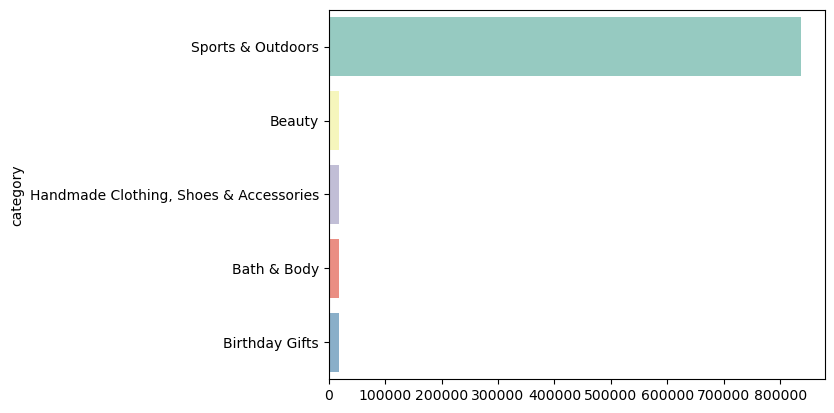

In [35]:
sns.barplot(y=frequency_table_top.index, x=frequency_table_top.values, palette="Set3", hue=frequency_table_top.index, legend=False)


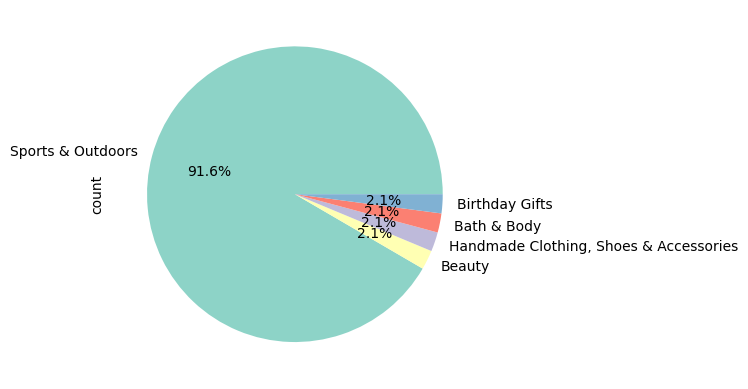

In [40]:
frequency_table_top.plot.pie(autopct="%.1f%%", startangle=360, colors=sns.color_palette("Set3"));
plt.show()

From this pie chart we can see there is one category that dominates most: Sport & Outdoors occupying a significant portion of the chart. 

### Part 2: Delving into Product Pricing

1. **Measures of Centrality**:

In [64]:
mean_price = df["price"].mean()
median_price = df["price"].median()
mode_price = df["price"].mode()

mean_price, median_price, mode_price

(np.float64(89.24380943923661),
 19.09,
 0    9.99
 Name: price, dtype: float64)

The average price point is 89.24, which is significantly higher than the most common price point, 9.99. The mean being higher than the mode could suggest that the price data is right-skewed meaning that the right-tail is longer than the left-tail so a significant number of products are being sold at higher prices.

2. **Measures of Dispersion**:

In [43]:
variance_price = df['price'].var() 
std_dev_price = df['price'].std()
min_price = df['price'].min()
max_price = df['price'].max()
range_price = max_price - min_price
quantiles_price = df['price'].quantile([0.25, 0.5, 0.75])

variance_price, std_dev_price, min_price, max_price, range_price, quantiles_price

(119445.4853225653,
 345.6088617535223,
 0.0,
 100000.0,
 100000.0,
 0.25     9.99
 0.50    19.09
 0.75    45.99
 Name: price, dtype: float64)


The product prices are very varied as we can see from the range, acting as a clear indicator of a significant spread in prices. 

3. **Visualizations**:

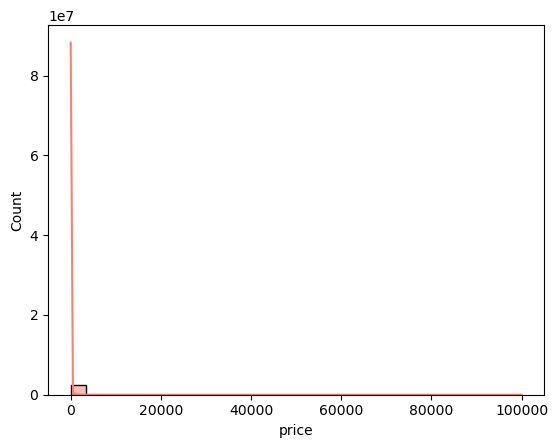

In [45]:
fig, axes = plt.subplots()
sns.histplot(df['price'], kde=True, bins=30, color="salmon", ax=axes);
plt.show()

The histogram shows a huge spike near 0 and then a very long empty tail up to ~100,000. This means that the price distribution is extremely right-skewed so the majority of the price data points are clustered on the left where the lower values are (i.e., most products are sold at lower prices) but the presence of extreme outliers causes the cheaper products to get compressed into a tiny area near zero making the plot difficult to interpret.

To solve this, we need to change the range of prices or exclude the extreme outliers. 

### Part 3: Unpacking Product Ratings
1. **Measures of Centrality**:

In [47]:
mean_rating = df["stars"].mean()
median_rating = df["stars"].median()
mode_rating = df["stars"].mode()

mean_rating, median_rating, mode_rating

(np.float64(2.152836472966066),
 0.0,
 0    0.0
 Name: stars, dtype: float64)

In [56]:
bins = [0, 1, 2, 3, 4, df['stars'].max()]
labels = ['Low', 'Medium', 'High', 'Very High', 'Extremely High']
df['stars_category'] = pd.cut(df['stars'], bins=bins, labels=labels, include_lowest=True)

df['stars_category'].value_counts()

stars_category
Low               1234125
Extremely High     965284
Very High          211623
High                27188
Medium               5431
Name: count, dtype: int64

The statistics indicate that many ratings are concentrated at the lower end of the scale, with the median rating being 0, meaning at least half of the products have very low ratings

2. **Measures of Dispersion**:

In [57]:
std_rating = df["stars"].std()
var_rating = df["stars"].var()
min_rating = df["stars"].min()
max_rating = df["stars"].max()
range_rating = max_rating - min_rating
quantiles_rating = df['stars'].quantile([0.25, 0.5, 0.75])

In [59]:
var_rating, std_rating, min_rating, max_rating, range_rating, quantiles_rating

(4.81743402976196,
 2.1948653785054697,
 0.0,
 5.0,
 5.0,
 0.25    0.0
 0.50    0.0
 0.75    4.4
 Name: stars, dtype: float64)

The ratings show considerable variation in customer feedback. The ratings range from 0 to 5, covering the full scale. The standard deviation of about 2.19 indicates that ratings are spread out rather than concentrated around the mean. Additionally, the quartiles show that many ratings are very low (median = 0) while others are much higher, suggesting polarized customer opinions.

3. **Shape of the Distribution**:

In [60]:
skewness_rating = df['stars'].skew()
kurtosis_rating = df['stars'].kurtosis()

skewness_rating, kurtosis_rating

(np.float64(0.08120735761080881), np.float64(-1.9260061280432994))

The skewness of the rating column is approximately 0.08, which is close to zero, indicating that the distribution is roughly symmetric with only a slight right skew. The kurtosis is approximately −1.93, suggesting the distribution is flatter than a normal distribution (platykurtic). Therefore, the ratings are not perfectly normally distributed and are somewhat spread out rather than strongly concentrated around the mean.

4. **Visualizations**:

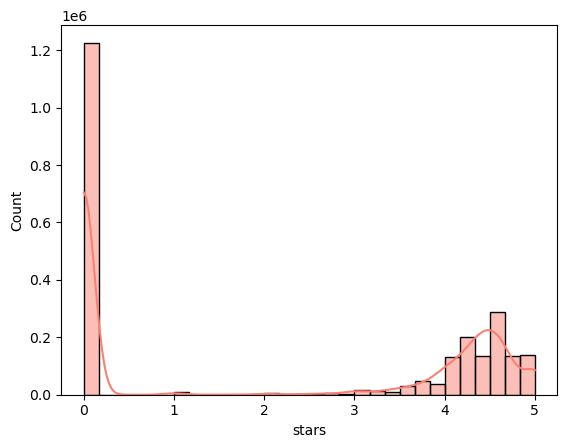

In [61]:
fig, axes = plt.subplots()
sns.histplot(df['stars'], kde=True, bins=30, color="salmon", ax=axes);
plt.show()

As shown by the histogram there is one rating that is more common than the rest; 0. 

### Conclusion: 

The five most popular product categories on Amazon UK are: Sports & Outdoors, Beauty, Handmade Clothing, Shoes & Accessories, Bath & Body, Birthday Gifts, respectively, with the dominant category being Sports & Outdoors, accounting for 34% of the most products ordered. Products on Amazon UK are generally priced at relatively low levels, with the most common price point around £9.99 and a median price of about £19, indicating that many products fall in the £10–£20 range. The majority of items are priced below £46, as shown by the upper quartile. However, a small number of very expensive products (up to £100,000) create a strong right-skewed distribution, increasing the mean price and producing extreme outliers. Customer ratings on Amazon UK are highly varied, with a noticeable concentration of low ratings but also a significant number of highly rated products. This indicates polarized customer feedback, where some products receive very poor ratings while others are rated very positively.
